In [33]:
# Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# Display Setup
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [34]:
# Dataset loading
try:
    # File path - if the file is in the project folder
    file_path = r"../../datasets/bank-additional/bank-additional-full.csv"
    df = pd.read_csv(file_path, sep=';')
    print("Dataset successfully loaded.")

except FileNotFoundError:
    url = "https://raw.githubusercontent.com/mkhazaeidev/DataMiningTutorial/main/datasets/bank-additional/bank-additional-full.csv"
    df = pd.read_csv(url, sep=';')
    print("Dataset successfully downloaded.")

    # print("Error: File not found. Please download from the link below:")
    # print("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip")

Dataset successfully loaded.


In [35]:
# Initial Exploration
print("First 5 rows of data:")
print(df.head())

print("\nLast 5 rows of data:")
print(df.tail())

# General information about the dataframe
print("\nShape information:")
print(
    f"Data dimensions: {df.shape} (number of rows: {df.shape[0]}, number of columns: {df.shape[1]})"
)
print("\nStructural Information:")
df.info()

print("\nNames of all columns:")
print(df.columns.tolist())
print(f"\nNumber of columns: {len(df.columns)}")

# Descriptive statistics
print("\nDescriptive statistics (numeric columns):")
print(df.describe())

print("\nDescriptive statistics (non-numeric columns):")
print(df.describe(include=['object']))

First 5 rows of data:
   age        job  marital    education  default housing loan    contact month day_of_week  duration  campaign  pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y
0   56  housemaid  married     basic.4y       no      no   no  telephone   may         mon       261         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
1   57   services  married  high.school  unknown      no   no  telephone   may         mon       149         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
2   37   services  married  high.school       no     yes   no  telephone   may         mon       226         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
3   40     admin.  married     basic.6y       no      no   no  telephone   may         mon       151         1    999     

In [36]:
print("Checking for Missing Values")

# Check for null values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing values ​​in each column:")
missing_info = pd.DataFrame({
    'column': df.columns,
    'missing_value': missing_data,
    'missing_percentage': missing_percent
})
print(missing_info[missing_info['missing_value'] > 0])
if missing_data.sum() == 0:
    print("There are no missing values ​in the data!")
else:
    print(f"Total missing values: {missing_data.sum()}")

Checking for Missing Values
Missing values ​​in each column:
Empty DataFrame
Columns: [column, missing_value, missing_percentage]
Index: []
There are no missing values ​in the data!


In [37]:
# Check for duplicate data"

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Percentage of duplicate data: {(duplicates/len(df))*100:.2f}%")
else:
    print("There are no duplicates")

Number of duplicate rows: 12
Percentage of duplicate data: 0.03%


Distribution of the target variable 'y':
Number:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


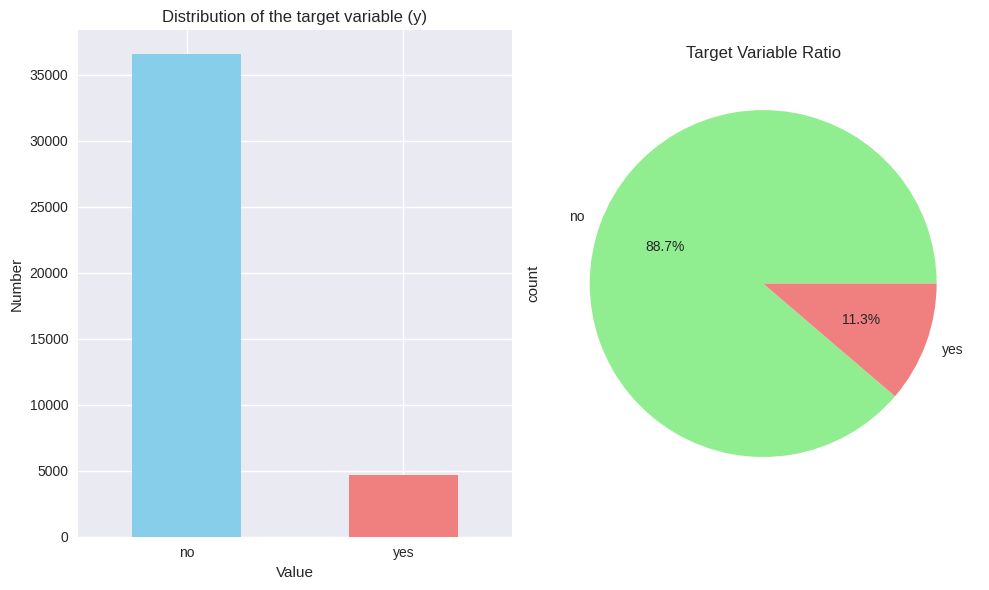


Data Balance Analysis:
Majority Class to Minority Class Ratio:     7.88 to 1
Solution: You can use techniques such as         class weighting or sampling were used


In [38]:
# Analysis of the target variable (y)

# Check the distribution of the target variable
target_column = 'y'  # This is our target column

print(f"Distribution of the target variable '{target_column}':")
target_distribution = df[target_column].value_counts()
target_percentage = df[target_column].value_counts(normalize=True) * 100

print("Number:")
print(target_distribution)
print("\nPercentage:")
print(target_percentage)

# Distribution of the target variable
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
df[target_column].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightcoral']
)
plt.title('Distribution of the target variable (y)')
plt.xlabel('Value')
plt.ylabel('Number')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df[target_column].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral']
)
plt.title('Target Variable Ratio')

plt.tight_layout()
plt.show()

# Data Balance Importance Analysis
print(f"\nData Balance Analysis:")
print(
    f"Majority Class to Minority Class Ratio: \
    {target_distribution.max()/target_distribution.min():.2f} to 1"
)

if target_percentage.max() / target_percentage.min() > 4:
    print("Warning: Data is unbalanced! This may affect model performance.")
    print(
        "Solution: You can use techniques such as \
        class weighting or sampling were used"
    )
else:
    print("The data is relatively balanced")

Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


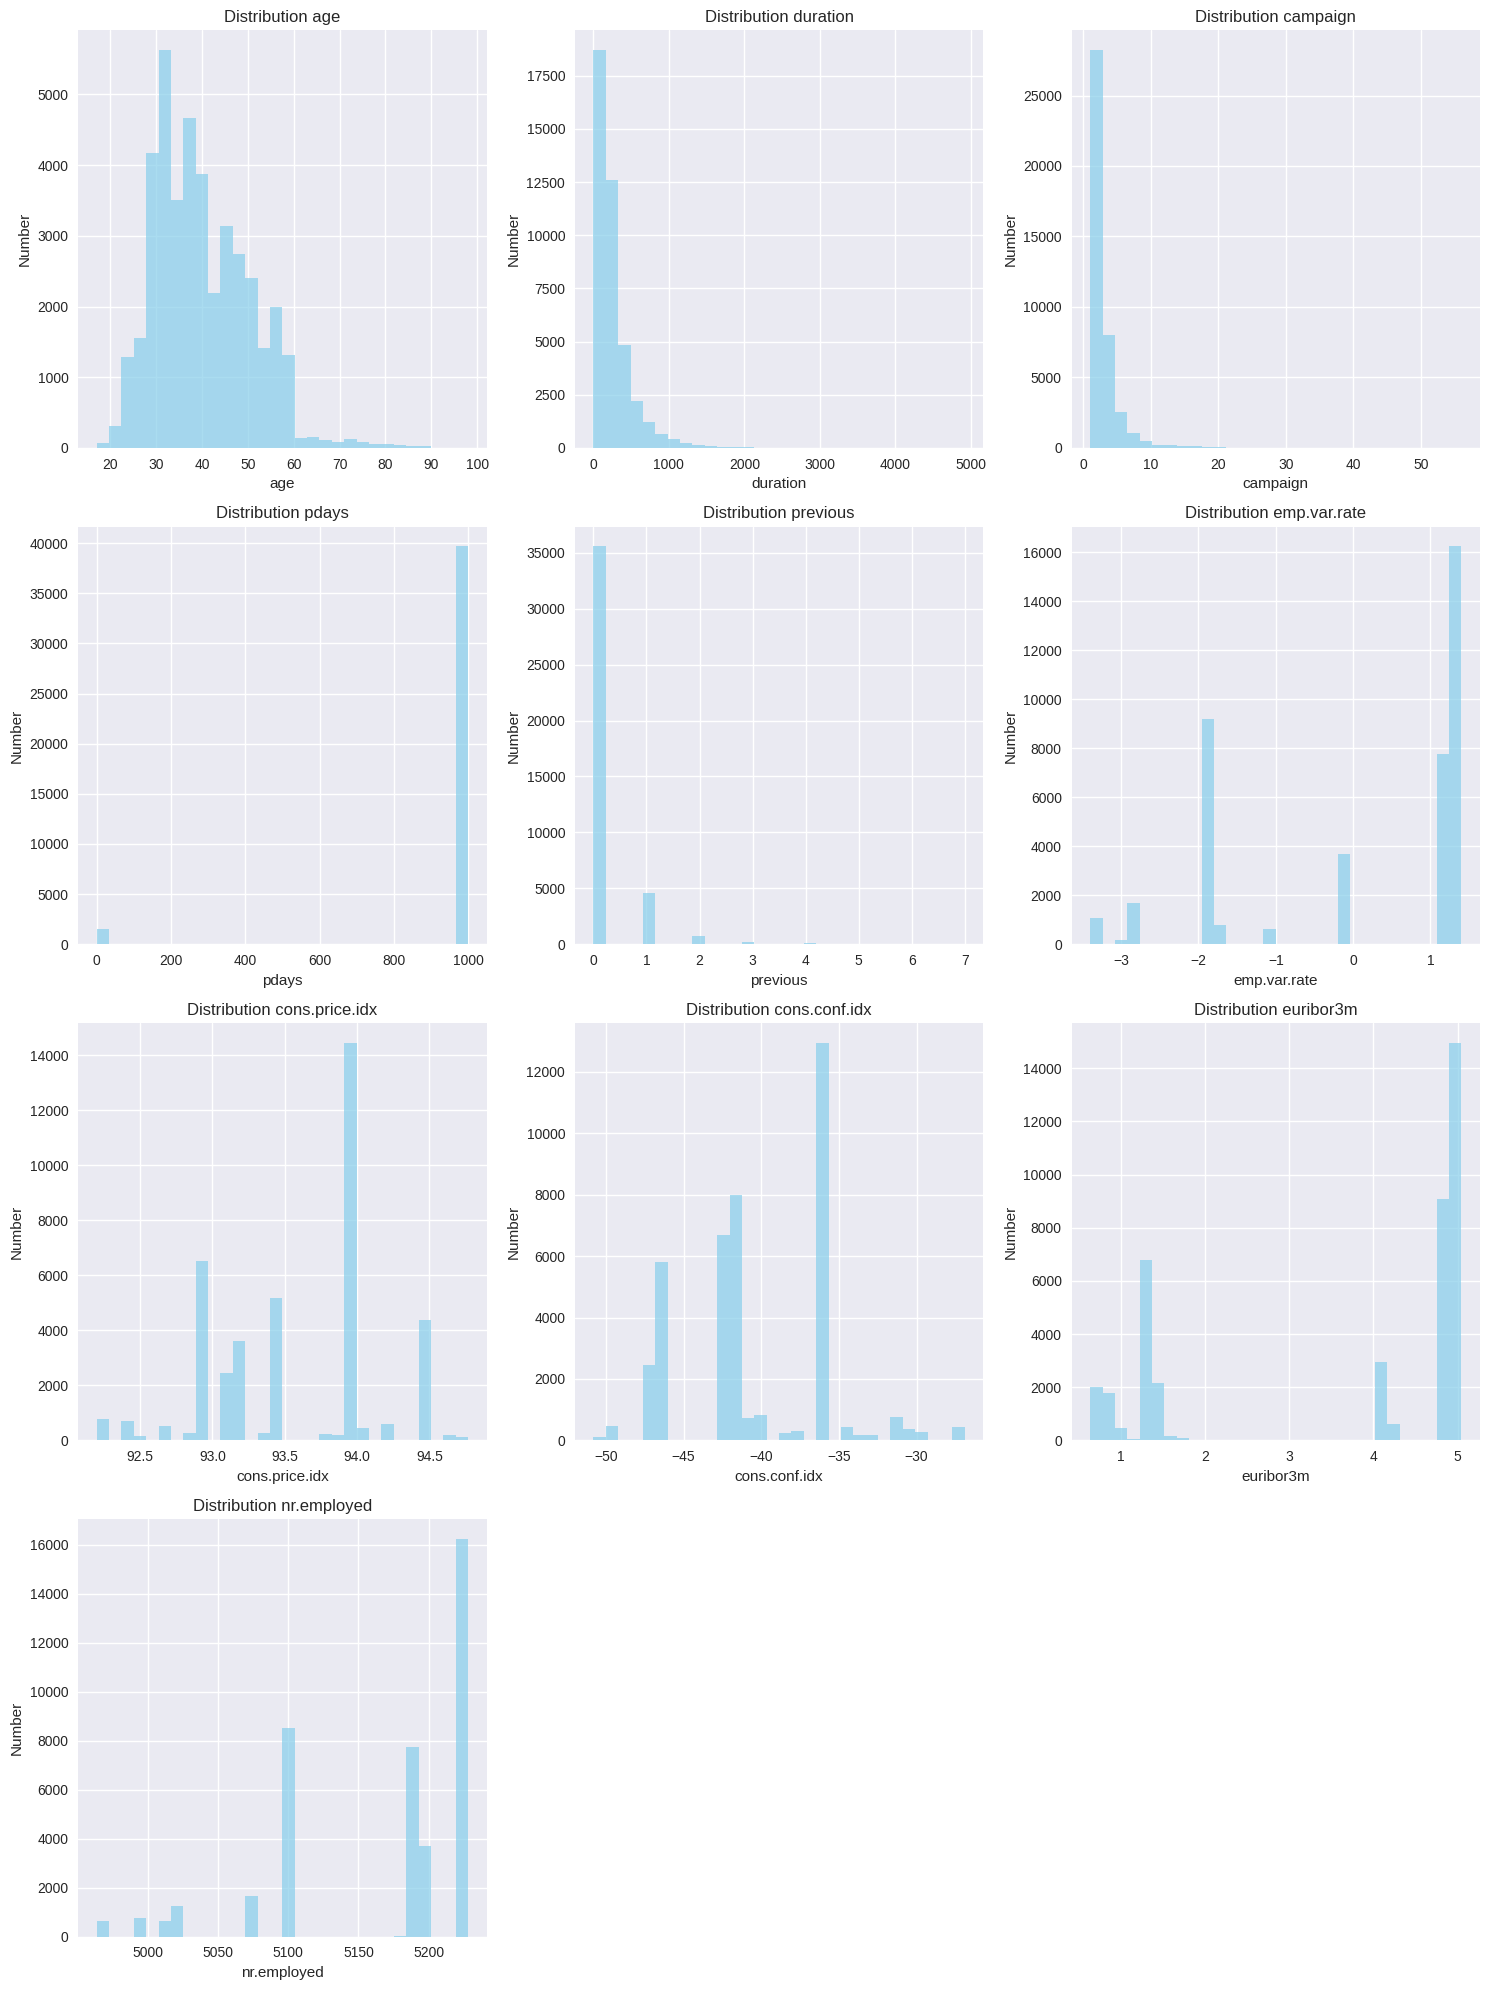

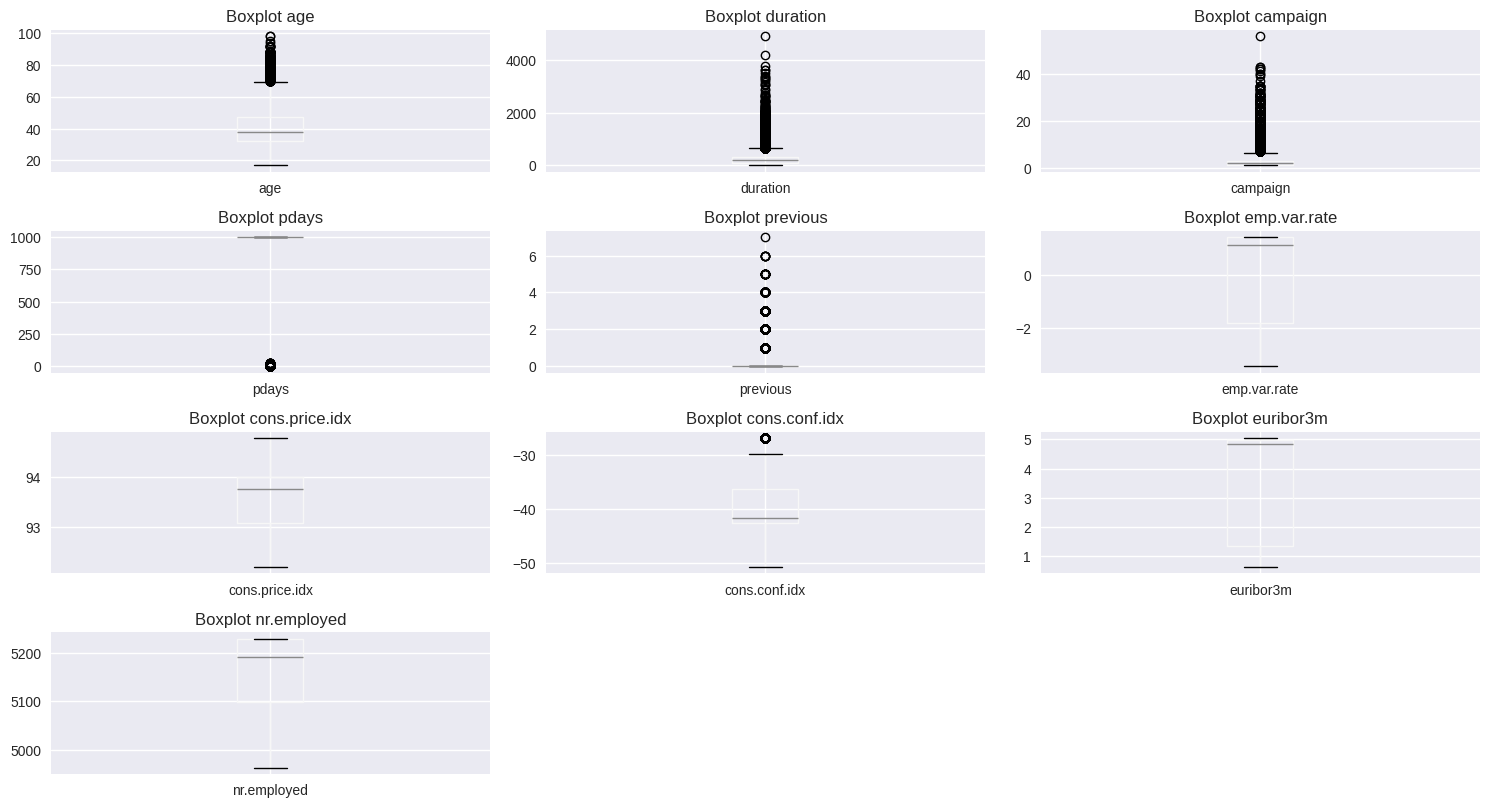

In [39]:
# Numerical Variables Analysis

# Identify numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {list(numeric_columns)}")

if len(numeric_columns) > 0:
    # Calculate network dimensions dynamically
    number_cols = len(numeric_columns)
    number_rows = (number_cols + 2) // 3

    # Histogram for all numeric variables
    plt.figure(figsize=(15, 5 * number_rows))

    for index, col in enumerate(numeric_columns):
        plt.subplot(number_rows, 3, index + 1)
        df[col].hist(bins=30, alpha=0.7, color='skyblue')
        plt.title(f'Distribution {col}')
        plt.xlabel(col)
        plt.ylabel('Number')

    plt.tight_layout()
    plt.show()

    # Boxplot for outlier detection
    plt.figure(figsize=(15, 5 * number_rows))
    for i, col in enumerate(numeric_columns):
        plt.subplot(number_cols, 3, i+1)
        df.boxplot(column=col)
        plt.title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found!")

🏷️ Non-numeric columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Analyze column 'job':
Number of unique values: 12
Values and their count:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: count, dtype: int64
This column has 12 unique values - may need grouping


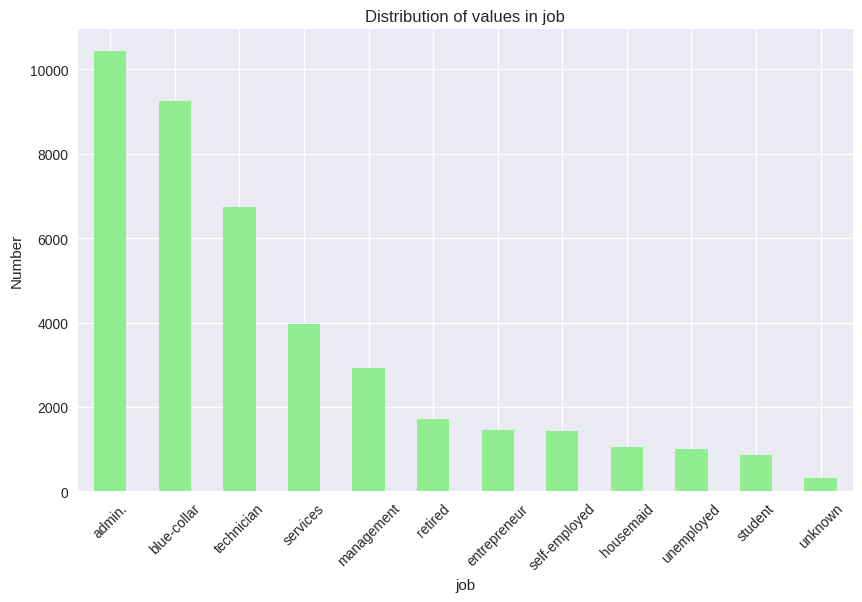


Analyze column 'marital':
Number of unique values: 4
Values and their count:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


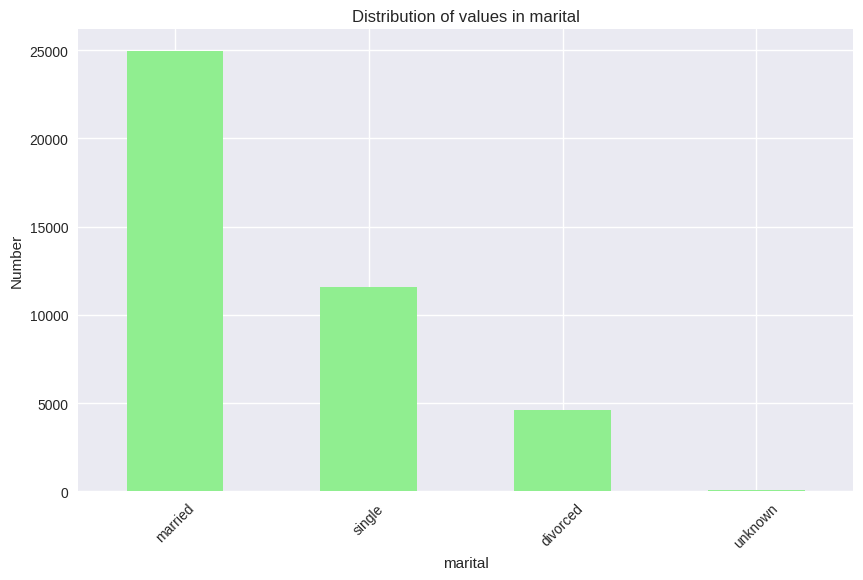


Analyze column 'education':
Number of unique values: 8
Values and their count:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


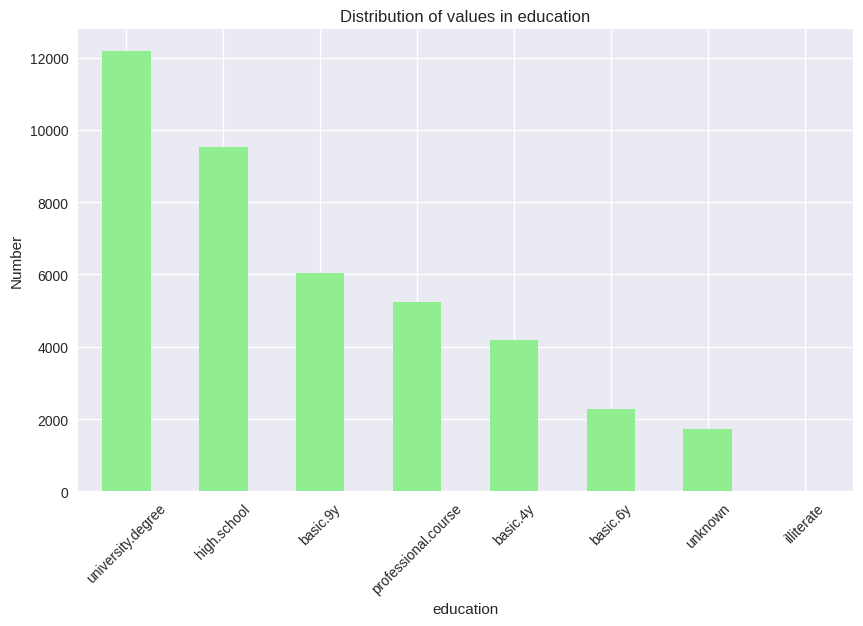


Analyze column 'default':
Number of unique values: 3
Values and their count:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


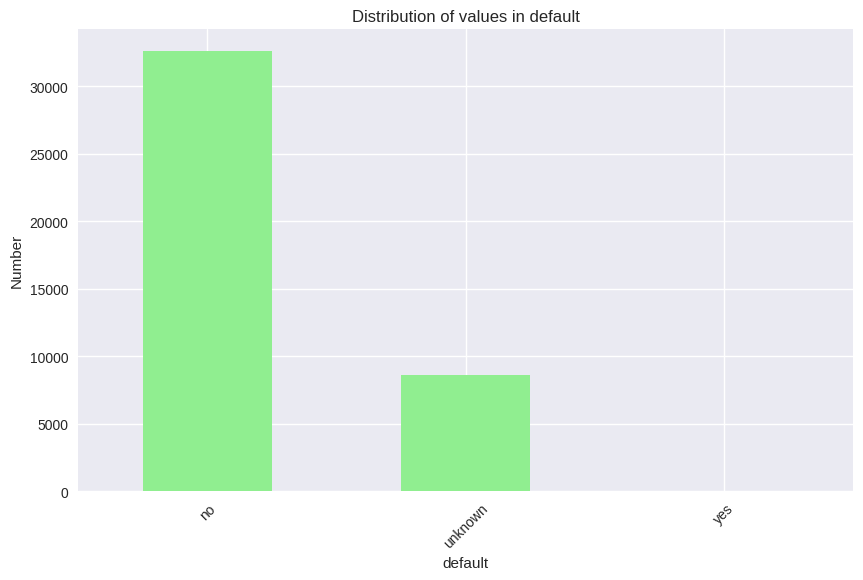


Analyze column 'housing':
Number of unique values: 3
Values and their count:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


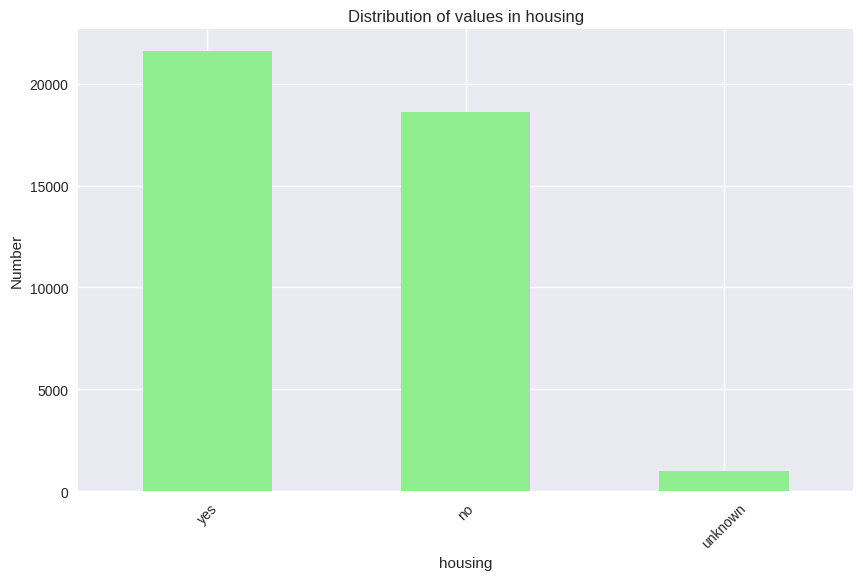


Analyze column 'loan':
Number of unique values: 3
Values and their count:
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


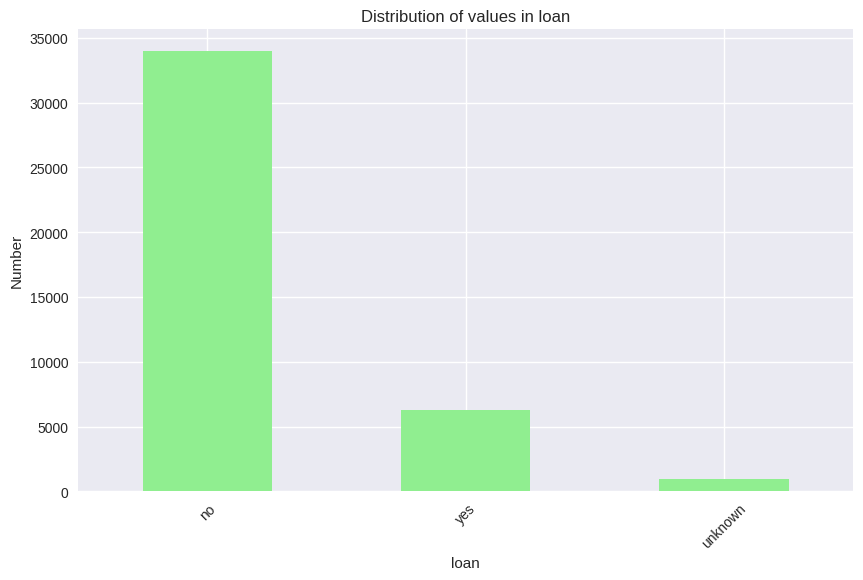


Analyze column 'contact':
Number of unique values: 2
Values and their count:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64


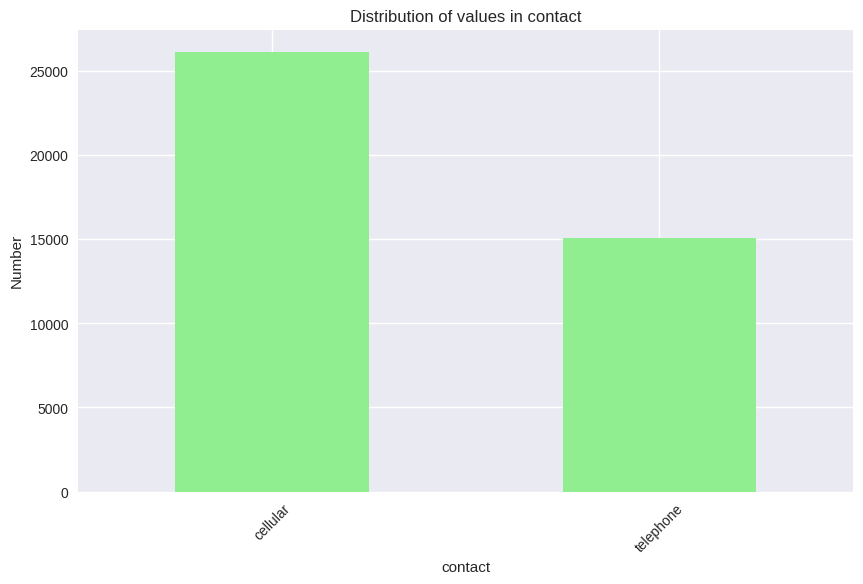


Analyze column 'month':
Number of unique values: 10
Values and their count:
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64


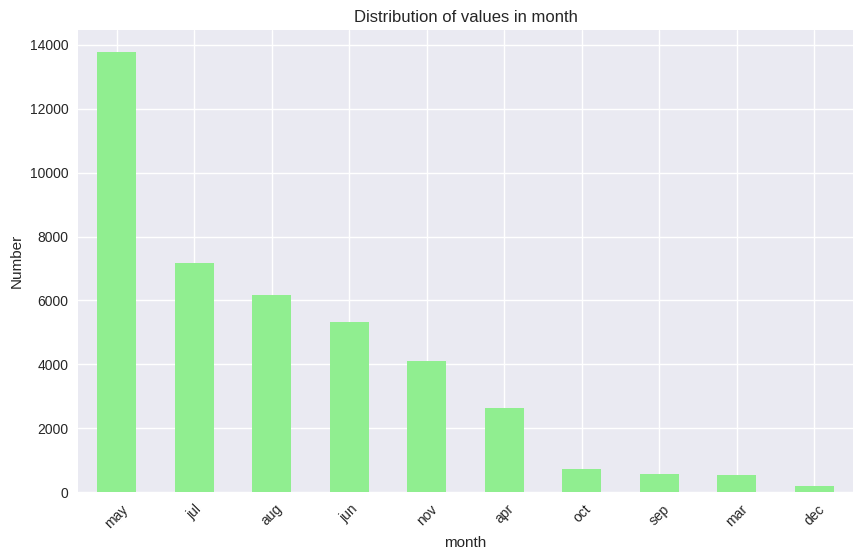


Analyze column 'day_of_week':
Number of unique values: 5
Values and their count:
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64


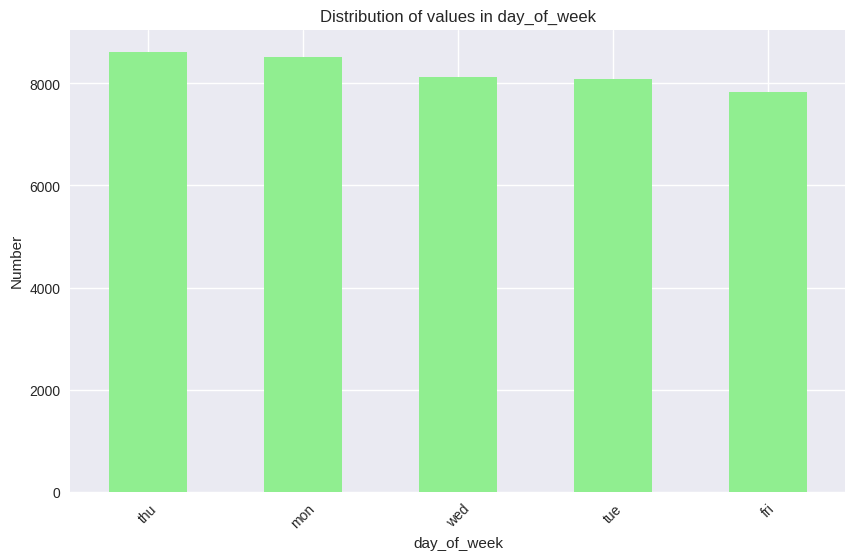


Analyze column 'poutcome':
Number of unique values: 3
Values and their count:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


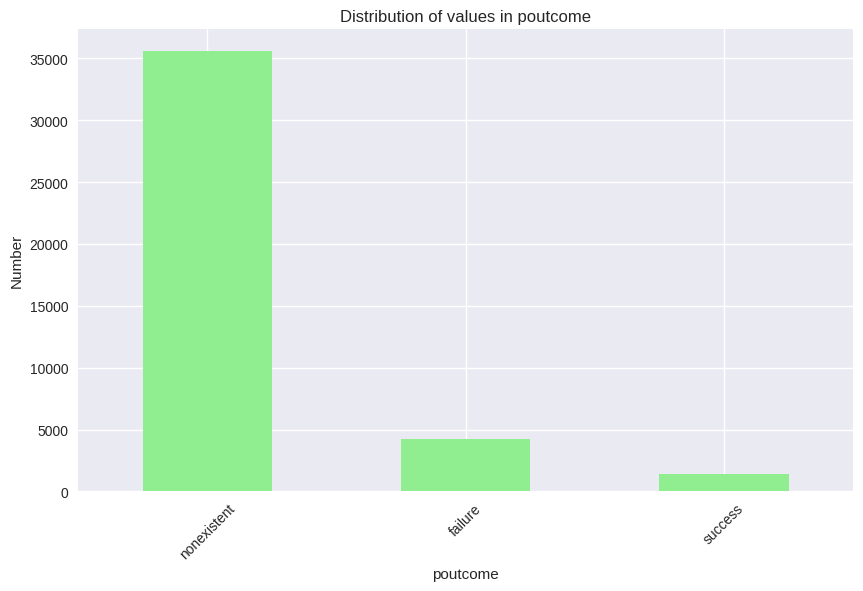


Analyze column 'y':
Number of unique values: 2
Values and their count:
y
no     36548
yes     4640
Name: count, dtype: int64


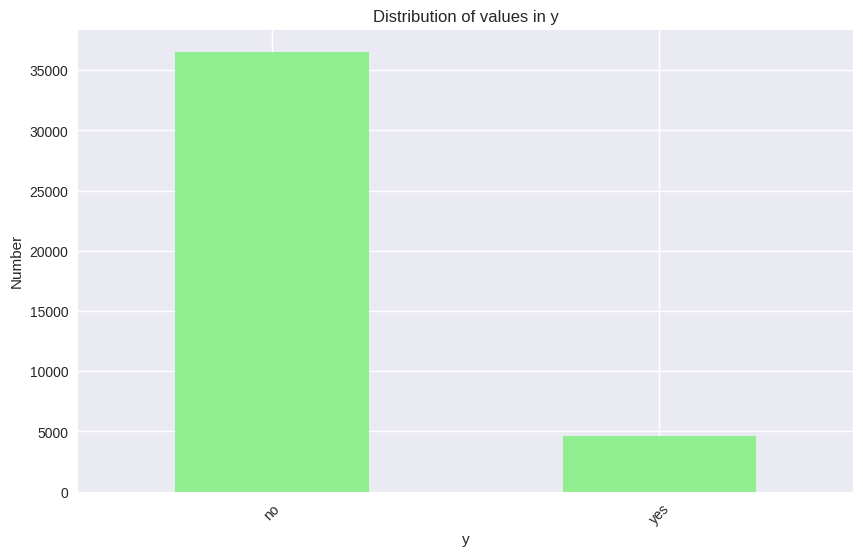

In [40]:
# Categorical Variables Analysis
# Identify non-numeric columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"🏷️ Non-numeric columns: {list(categorical_columns)}")

if len(categorical_columns) > 0:
    # Analyze each non-numeric column
    for col in categorical_columns:
        print(f"\nAnalyze column '{col}':")
        unique_values = df[col].nunique()
        value_counts = df[col].value_counts()

        print(f"Number of unique values: {unique_values}")
        print("Values and their count:")
        print(value_counts.head(10))  # Only the first 10 values

        if unique_values > 10:
            print(f"This column has {unique_values} unique values - may need grouping")

        # Chart for columns with Value limit
        if unique_values <= 15:
            plt.figure(figsize=(10, 6))
            value_counts.plot(kind='bar', color='lightgreen')
            plt.title(f'Distribution of values in {col}')
            plt.xlabel(col)
            plt.ylabel('Number')
            plt.xticks(rotation=45)
            plt.show()
else:
    print("No non-numeric columns found!")


Relationship between 'job' and 'y':
y                     no        yes
job                                
admin.         87.027442  12.972558
blue-collar    93.105684   6.894316
entrepreneur   91.483516   8.516484
housemaid      90.000000  10.000000
management     88.782490  11.217510
retired        74.767442  25.232558
self-employed  89.514426  10.485574
services       91.861930   8.138070
student        68.571429  31.428571
technician     89.173958  10.826042
unemployed     85.798817  14.201183
unknown        88.787879  11.212121


<Figure size 1000x600 with 0 Axes>

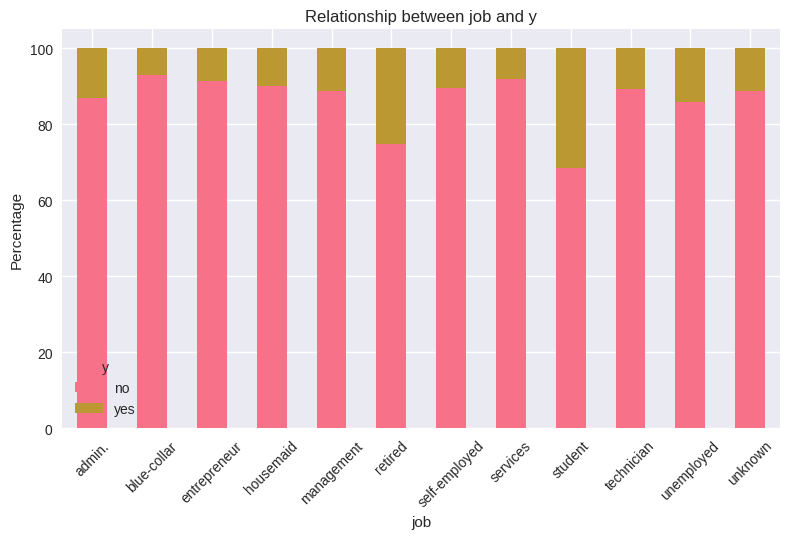


Relationship between 'marital' and 'y':
y                no        yes
marital                       
divorced  89.679098  10.320902
married   89.842747  10.157253
single    85.995851  14.004149
unknown   85.000000  15.000000


<Figure size 1000x600 with 0 Axes>

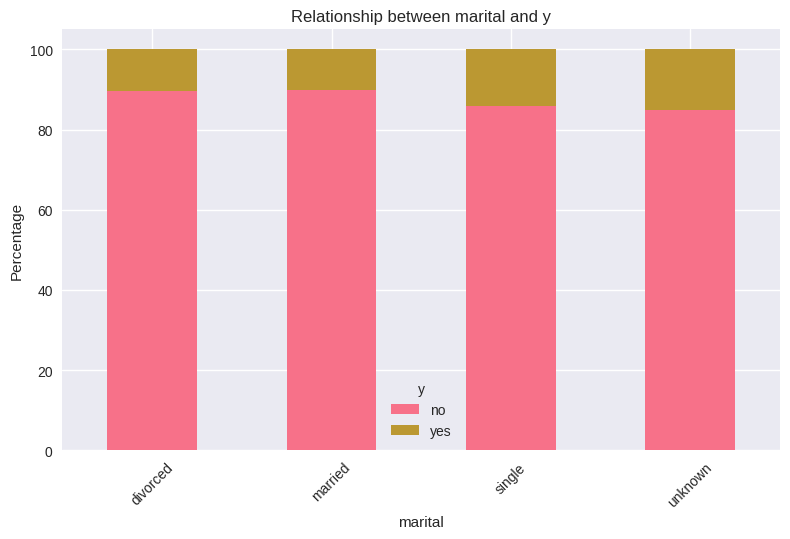


Relationship between 'education' and 'y':
y                           no        yes
education                                
basic.4y             89.750958  10.249042
basic.6y             91.797557   8.202443
basic.9y             92.175352   7.824648
high.school          89.164477  10.835523
illiterate           77.777778  22.222222
professional.course  88.651535  11.348465
university.degree    86.275477  13.724523
unknown              85.499711  14.500289


<Figure size 1000x600 with 0 Axes>

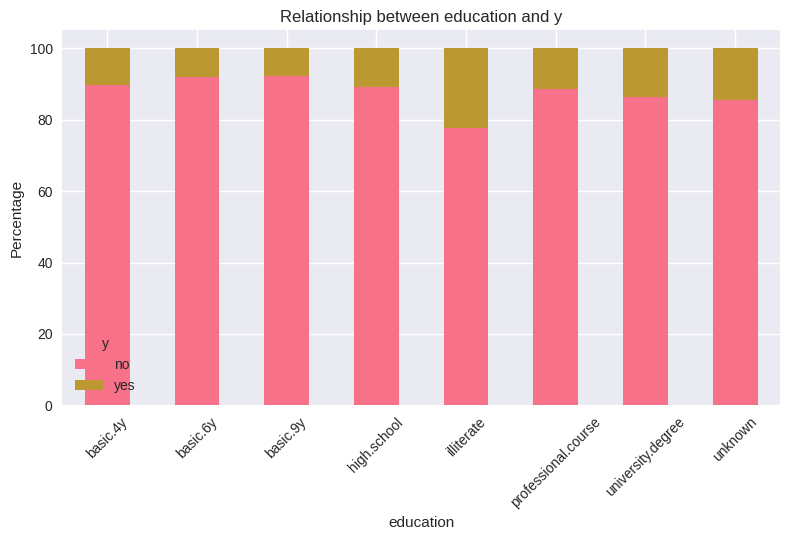


Relationship between 'default' and 'y':
y                no        yes
default                       
no        87.121026  12.878974
unknown   94.847040   5.152960
yes      100.000000   0.000000


<Figure size 1000x600 with 0 Axes>

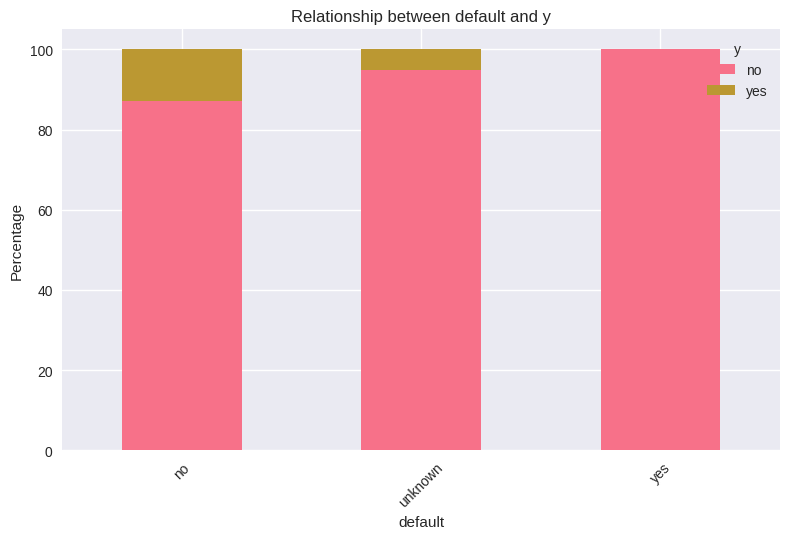


Relationship between 'housing' and 'y':
y               no        yes
housing                      
no       89.120395  10.879605
unknown  89.191919  10.808081
yes      88.380608  11.619392


<Figure size 1000x600 with 0 Axes>

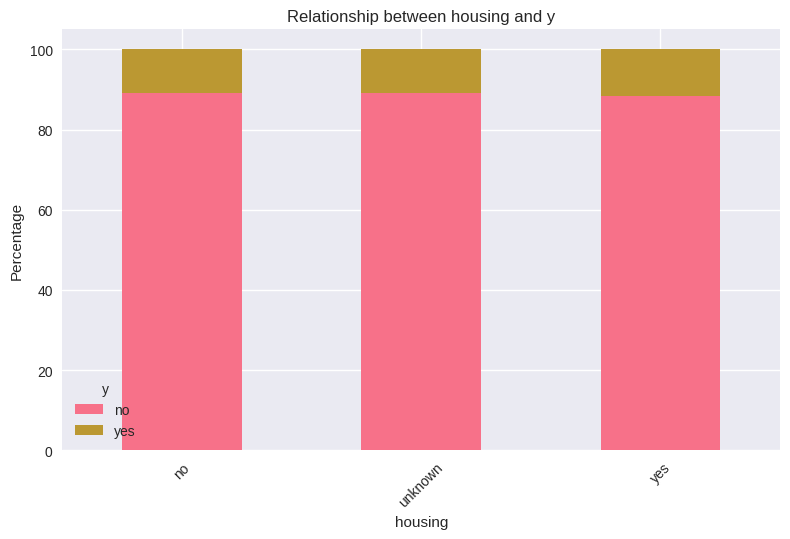


Relationship between 'loan' and 'y':
y               no        yes
loan                         
no       88.659794  11.340206
unknown  89.191919  10.808081
yes      89.068502  10.931498


<Figure size 1000x600 with 0 Axes>

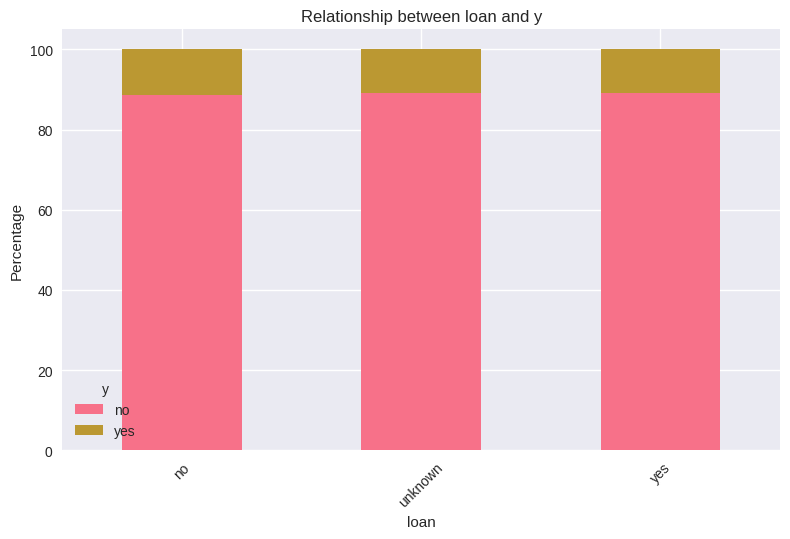

In [41]:
# Preliminary Relationship Analysis

# Analyze the relationship between several important variables and the target variable
important_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in important_columns:
    if col in df.columns:
        print(f"\nRelationship between '{col}' and '{target_column}':")
        cross_tab = pd.crosstab(df[col], df[target_column], normalize='index') * 100
        print(cross_tab)

        # Chart
        plt.figure(figsize=(10, 6))
        cross_tab.plot(kind='bar', stacked=True)
        plt.title(f'Relationship between {col} and {target_column}')
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.legend(title=target_column)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()